# CMSE 201 Final Project 

## Introduction

Title: "USDA Rural Development Multifamily Section 515 Rural Rental Housing and Section 514 Farm Labor Housing Tenant Characteristics"

Dataset:"https://catalog.data.gov/dataset/usda-rural-development-multifamily-section-515-rural-rental-housing-and-section-514-farm-l-a4949?from_hint=eyJxIjoidXNkYSBydXJhbCBkZXZlbG9wbWVudCBtdWx0aWZhbWlseSBzZWN0aW9uIDUxNSBydXJhbCByZW50YWwgaG91c2luZyBhbmQgc2VjdGlvbiA1MTQgZmFybSIsInNvcnQiOiJyZWxldmFuY2UifQ%3D%3D"

**Background and Motivation**: The data above is collected by the USDA and published by Rural Development, Department of Agriculture. The data includes property address and aggregated demographic information including female headed-households, elderly aged 62 or older, minors, disability status, race, and ethnicity. Also includes average annual income, average annual income by source of income, cost-burden indicator, zero income indicator, and rental assistance subsidy counts by type of assistance.

**Data Or Algorithm Context**: How do worker wages and government subsidies affect the quality of life of farmworkers? How does this differ by state? I'm focusing on government aided income (public assistance and social security) by state.


## Data Analysis

In [34]:
import pandas as pd

In [35]:
#loading in data
data = pd.read_csv("farmworker_housing.csv")

In [36]:
#printing first 10 lines of dataset
data.head(10)

,#Borrower_ID,Project_ID,Project_Check_Digit,State_County_FIPS_Code,Project_Name,Main_Address_Line1,Main_Address_Line2,Main_Address_Line3,City,State_Abbreviation,...,Subsidy_2_Count,Subsidy_4_Count,Subsidy_5_Count,Subsidy_6_Count,Subsidy_7_Count,Subsidy_8_Count,Annual_Income_Average,Other_Income_Average,Public_Assistant_Income_Average,Social_Security_Income_Average
0,485335461,2,2,18019,MAPLE LEAF APTS.,228 MAPLE DRIVE,,,CHARLESTOWN,IN,...,40,0,0,0,0,0,11599.95,1434.77,0.00,5964.14
1,256730658,2,2,18019,WINDSOR APARTMENTS,328 MAPLE DRIVE,,,CHARLESTOWN,IN,...,0,0,0,55,0,0,14313.40,848.67,0.00,7077.13
2,299320453,1,2,18019,RIDGEVIEW LIMITED,1418 MT. ZION RD.,,,HENRYVILLE,IN,...,0,0,0,1,0,0,15239.73,0.00,0.00,11785.09
3,74538105,1,9,18029,RIDGE PARK APT,1175 FOREST DRIVE,,,GREENDALE,IN,...,0,0,0,1,0,0,18397.62,265.68,0.00,5344.00
4,57764175,1,0,18029,KNOLL PARK APT.,2512 KNOLL CT.,,,LAWRENCEBURG,IN,...,0,0,0,0,0,0,23264.43,798.48,0.00,4897.48
5,495021454,1,4,18029,RIVER PARK APTS.,439 PARK AVE.,,,AURORA,IN,...,0,0,0,2,0,0,15790.05,0.00,0.00,14195.11
6,88359548,1,3,18029,VILLAGE APARTMENTS OF LAWRENCEBURG,,60 DOUGHTY ROAD,NaN,LAWRENCEBURG,IN,...,0,0,0,2,0,0,13845.00,348.72,42.77,12941.28
7,8934827,1,2,18077,RAINBOW END APARTMENTS II,500 RAINBOW LANE,,,HANOVER,IN,...,0,0,0,0,0,0,19915.27,0.00,0.00,12067.73
8,8934827,2,2,18077,RAINBOW END APARTMENTS I,500 RAINBOW LANE,,,HANOVER,IN,...,0,0,0,9,0,0,13955.17,258.50,0.00,7737.75
9,760181972,1,3,18077,CLIFTON HEIGHTS APARTMENTS,401 VIRGINIA AVE,,,MADISON,IN,...,0,0,0,12,0,0,14421.76,529.27,0.00,10096.76


In [37]:
#filtering the data for only the columns I'm working with
new_data = data[[ "City", "State_Abbreviation", "Public_Assistant_Income_Average","Social_Security_Income_Average"]] 

In [38]:
#Dropping any data that included "Na"
new_data.dropna()

,City,State_Abbreviation,Public_Assistant_Income_Average,Social_Security_Income_Average
0,CHARLESTOWN,IN,0.00,5964.14
1,CHARLESTOWN,IN,0.00,7077.13
2,HENRYVILLE,IN,0.00,11785.09
3,GREENDALE,IN,0.00,5344.00
4,LAWRENCEBURG,IN,0.00,4897.48
...,...,...,...,...
13542,SALINAS,CA,0.00,4364.52
13543,ARCADE,NY,162.10,11210.51
13546,HARRISONBURG,LA,0.00,13703.27
13547,CULLEN,LA,0.00,9218.70


## Creating datasets for each state

In [39]:
#CALIFORNIA
mask= new_data["State_Abbreviation"] == "CA"

california = new_data[mask]

In [40]:
# IOWA
iowa = new_data["State_Abbreviation"] == "IA"
iowa = new_data[iowa]

In [41]:
# NEBRASKA
nebraska = new_data["State_Abbreviation"] == "NE"
nebraska = new_data[nebraska]

In [42]:
# TEXAS
texas = new_data["State_Abbreviation"] == "TX"
texas = new_data[texas]

In [43]:
# ILLINOIS
illinois = new_data["State_Abbreviation"] == "IL"
illinois = new_data[illinois]

In [44]:
# MINNESOTA
minnesota = new_data["State_Abbreviation"] == "MN"
minnesota = new_data[minnesota]

In [45]:
# KANSAS
kansas = new_data["State_Abbreviation"] == "KS"
kansas = new_data[kansas]

In [46]:
# INDIANA
indiana = new_data["State_Abbreviation"] == "IN"
indiana = new_data[indiana]

In [47]:
# NORTH CAROLINA
north_carolina = new_data["State_Abbreviation"] == "NC"
north_carolina = new_data[north_carolina]

In [48]:
# WISCONSIN
wisconsin = new_data["State_Abbreviation"] == "WI"
wisconsin = new_data[wisconsin]

## Methodology

In [49]:
#calculating states income total

#function to calculate publis assistance and social security
def income_total(state):
    pai = 0
    ssi = 0
    for row in state["Public_Assistant_Income_Average"]:
        pai += int(row)
    for row in state["Social_Security_Income_Average"]:
        ssi += int(row)
    return (pai/len(state), ssi/len(state))



states = ["california", "nebraska", "iowa", "texas", "illinois", "minnesota", "kansas", "indiana", "north carolina", "wisconsin"]


# Map string names to their DataFrame variables
state_dfs = {
    "california": california,
    "nebraska": nebraska,
    "iowa": iowa,
    "texas": texas,
    "illinois" : illinois, 
    "minnesota": minnesota,
    "kansas": kansas, 
    "indiana": indiana, 
    "north_carolina": north_carolina,
    "wisconsin": wisconsin
}

# Build the dictionary
us_assistance = {}
for state_name, state_df in state_dfs.items():
    us_assistance[state_name.capitalize()] = income_total(state_df)

print(us_assistance) #printing dictionary

{'California': (706.9635316698657, 6537.531669865643), 'Nebraska': (85.88461538461539, 8753.560439560439), 'Iowa': (43.45923913043478, 10810.578804347826), 'Texas': (31.516535433070867, 8262.489763779527), 'Illinois': (45.854581673306775, 8644.721115537848), 'Minnesota': (327.33475479744135, 9124.392324093817), 'Kansas': (32.541044776119406, 10274.936567164179), 'Indiana': (11.895089285714286, 9892.200892857143), 'North_carolina': (35.70338983050848, 8347.701694915255), 'Wisconsin': (28.20402298850575, 10777.1091954023)}


In [50]:
states = list(us_assistance.keys())
#Turning pai and ssi values into arrays to plot
pai_values = np.array([v[0] for v in us_assistance.values()])
ssi_values = np.array([v[1] for v in us_assistance.values()])

#creating a new dictionary for public assistance and social security income
assistance_data = {
    'Public Assistance Income': pai_values,
    'Social Security Income': ssi_values,
}

## Results

In [51]:
import matplotlib.pyplot as plt
import numpy as np

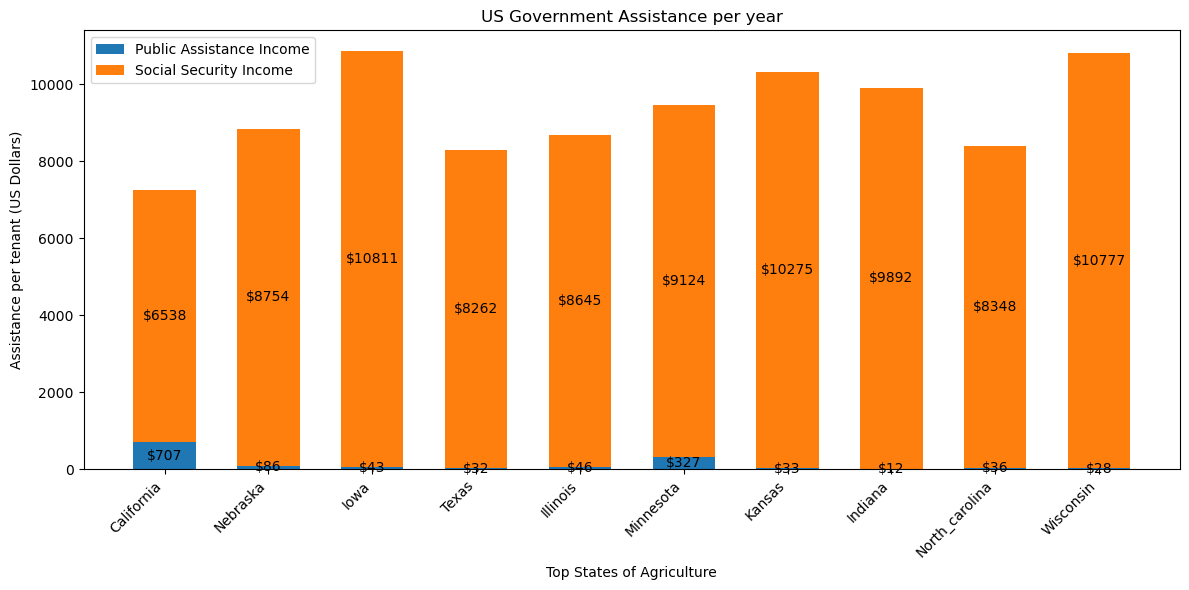

In [52]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.ticklabel_format(useOffset=False, style='plain')

bottom = np.zeros(len(states))

for label, values in assistance_data.items():
    p = ax.bar(states, values, 0.6, label=label, bottom=bottom)
    ax.bar_label(p, label_type='center', fmt='$%.0f')
    bottom += values

ax.set_title('US Government Assistance per year')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.ylabel("Assistance per tenant (US Dollars)")
plt.xlabel("Top States of Agriculture")
plt.tight_layout()
plt.savefig("US_Assistance.png")

## Synthesis

**Synthesis and Discussion**: With states with more social security income, there is most likely a higher elder population. I noticed that California was the state with the lowest social security income yet the highest for public assistance income. It made me think why a state as big as Texas wouldn't provide about the same or more than California. The data above is measured per capita so per household under section 514/515 this is the amount they're recieving per year on average. Although not direct, there is a correlation between public assistance and quality of life. Public assistance provides financial aid, food, housing, and medical benefits to eligible low-income individuals and families via federal, state, and local governments. For farmers under section 514/515 these could all improve their life. For states like Indiana where the average public assistance is $12 there's not much room to have access to all of these resources therefore they must rely on their wages. 